In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

# 1. 데이터 로드
df = pd.read_csv('./machine_failure.csv')

# 2. 고장 데이터만 사용
df_failure = df[df['Machine failure'] == 1].copy()

rename_map = {
    'Air temperature [K]': 'air_temp',
    'Process temperature [K]': 'process_temp',
    'Rotational speed [rpm]': 'rpm',
    'Torque [Nm]': 'torque',
    'Tool wear [min]': 'tool_wear'
}

df_failure = df_failure.rename(columns=rename_map)

print("고장 데이터 수:", len(df_failure))

# 3. 고장 유형 라벨 생성
def get_failure_type(row):
    if row['TWF'] == 1: return 0
    if row['HDF'] == 1: return 1
    if row['PWF'] == 1: return 2
    if row['OSF'] == 1: return 3
    if row['RNF'] == 1: return 4

df_failure = df_failure[
    df_failure[['TWF','HDF','PWF','OSF','RNF']].sum(axis=1) == 1
].copy()

df_failure['failure_type'] = df_failure.apply(get_failure_type, axis=1)

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

# 4. Feature 구성 (모델 1과 통일)
features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear'
]

# 파생 변수
df_failure['Temp_Diff'] = df_failure['process_temp'] - df_failure['air_temp']
df_failure['Power'] = df_failure['rpm'] * df_failure['torque']

features += ['Temp_Diff', 'Power']

X = df_failure[features]
y = df_failure['failure_type']

# 5. Train/Test 분리 (고장 유형 비율 유지!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. SMOTE (고장 유형 불균형 해결)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 7. 모델 정의 (다중분류)
model2 = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    class_weight='balanced',
    random_state=42
)

# 8. 학습
model2.fit(X_train_res, y_train_res)

# 9. 평가
y_pred = model2.predict(X_test)


input_data = {
    'air_temp': 305.0,
    'process_temp': 310.0,
    'rpm': 1450,
    'torque': 28.0,
    'tool_wear': 130
}

input_df = pd.DataFrame([input_data])

# 파생 변수 추가 (학습과 동일!)
input_df['temp_diff'] = input_df['process_temp'] - input_df['air_temp']
input_df['power'] = input_df['rpm'] * input_df['torque']

features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear',
    'temp_diff',
    'power'
]

X_input = input_df[features]

probs = model2.predict_proba(X_input)[0]

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

top2 = np.argsort(probs)[::-1][:2]

print("🔍 고장 원인 예측 Top-2")
for idx in top2:
    print(f"- {failure_map[idx]} 가능성: {probs[idx]*100:.1f}%")


고장 데이터 수: 339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 622
[LightGBM] [Info] Number of data points in the train set: 340, number of used features: 7
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

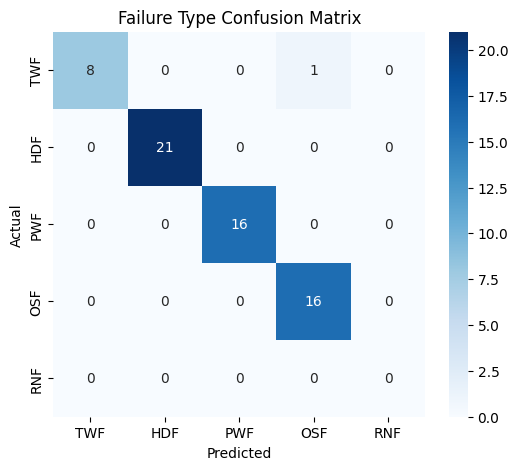

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2,3,4])

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['TWF','HDF','PWF','OSF','RNF'],
    yticklabels=['TWF','HDF','PWF','OSF','RNF'],
    cmap='Blues'
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Failure Type Confusion Matrix')
plt.show()

In [45]:
input_data = {
    'air_temp': 300.0,
    'process_temp': 310.0,
    'rpm': 850,
    'torque': 15.0,
    'tool_wear': 110
}

input_df = pd.DataFrame([input_data])

# 파생 변수 추가 (학습과 동일!)
input_df['temp_diff'] = input_df['process_temp'] - input_df['air_temp']
input_df['power'] = input_df['rpm'] * input_df['torque']

features = [
    'air_temp',
    'process_temp',
    'rpm',
    'torque',
    'tool_wear',
    'temp_diff',
    'power'
]

X_input = input_df[features]

probs = model2.predict_proba(X_input)[0]

failure_map = {
    0: 'TWF',
    1: 'HDF',
    2: 'PWF',
    3: 'OSF',
    4: 'RNF'
}

top2 = np.argsort(probs)[::-1][:2]

print("🔍 고장 원인 예측 Top-2")
for idx in top2:
    print(f"- {failure_map[idx]} 가능성: {probs[idx]*100:.1f}%")

🔍 고장 원인 예측 Top-2
- PWF 가능성: 94.5%
- TWF 가능성: 4.9%
